In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
data = pd.read_csv('/content/Video_Games_Sales.csv')

# Convert year column
data['Year_of_Release'] = pd.to_datetime(data['Year_of_Release'], format='%Y', errors='coerce')

# Remove missing values
data = data.dropna(subset=['Year_of_Release', 'Global_Sales'])

# Set index
data.set_index('Year_of_Release', inplace=True)

# Yearly total sales
data = data[['Global_Sales']].resample('YE').sum()

# Replace zero sales to avoid log error
data['Global_Sales'] = data['Global_Sales'].replace(0, 0.01)

# Regular differencing
data['sales_diff'] = data['Global_Sales'].diff()

# Seasonal decomposition
result1 = seasonal_decompose(data['Global_Sales'], model='additive', period=3)
data['sales_sea_diff'] = result1.resid

# Log transform
data['sales_log'] = np.log(data['Global_Sales'])

# Log differencing
data['sales_log_diff'] = data['sales_log'].diff()

# Remove NaN and inf values before decomposition
clean_log_diff = data['sales_log_diff'].replace([np.inf, -np.inf], np.nan).dropna()

# Seasonal decomposition after log diff
result2 = seasonal_decompose(clean_log_diff, model='additive', period=3)

# Add back to dataframe
data.loc[clean_log_diff.index, 'sales_log_seasonal_diff'] = result2.resid

# Plotting
plt.figure(figsize=(16,16))

<Figure size 1600x1600 with 0 Axes>

<Figure size 1600x1600 with 0 Axes>

Text(0.5, 1.0, 'Original Global Sales')

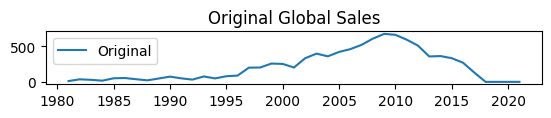

In [ ]:
plt.subplot(6,1,1)
plt.plot(data['Global_Sales'], label='Original')
plt.legend()
plt.title('Original Global Sales')

Text(0.5, 1.0, 'Regular Differencing')

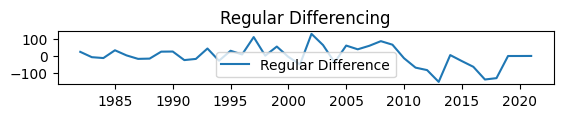

In [ ]:
plt.subplot(6,1,2)
plt.plot(data['sales_diff'], label='Regular Difference')
plt.legend()
plt.title('Regular Differencing')

Text(0.5, 1.0, 'Seasonal Adjustment')

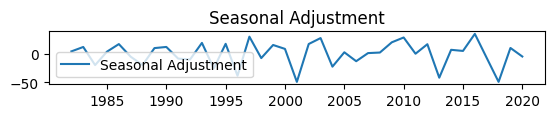

In [ ]:
plt.subplot(6,1,3)
plt.plot(data['sales_sea_diff'], label='Seasonal Adjustment')
plt.legend()
plt.title('Seasonal Adjustment')

Text(0.5, 1.0, 'Log Transformation')

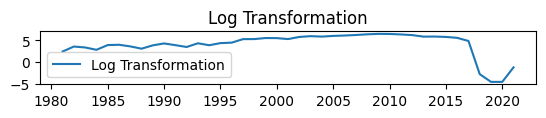

In [ ]:
plt.subplot(6,1,4)
plt.plot(data['sales_log'], label='Log Transformation')
plt.legend()
plt.title('Log Transformation')

Text(0.5, 1.0, 'Log Transformation + Differencing')

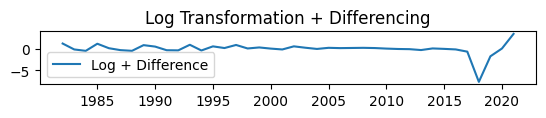

In [ ]:
plt.subplot(6,1,5)
plt.plot(data['sales_log_diff'], label='Log + Difference')
plt.legend()
plt.title('Log Transformation + Differencing')

Text(0.5, 1.0, 'Log + Differencing + Seasonal')

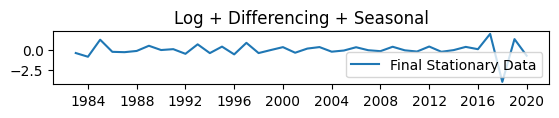

In [ ]:
plt.subplot(6,1,6)
plt.plot(data['sales_log_seasonal_diff'], label='Final Stationary Data')
plt.legend()
plt.title('Log + Differencing + Seasonal')

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

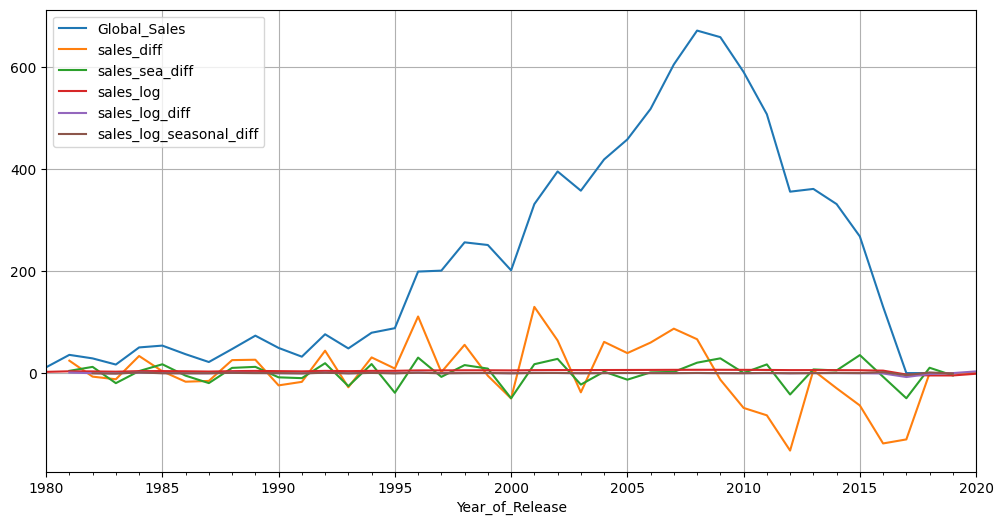

In [ ]:
data.plot(kind='line', figsize=(12,6))
plt.grid(True)
plt.show()